# Concept Vector Diagnostics

Validates that the extracted concept vectors (Lindsey et al. method) encode meaningful,
concept-specific information. Experiments ordered by speed:

1. **Experiment 3** — Concept vector norm profile across layers (are injection strengths meaningful?)
2. **Experiment 1** — Pairwise cosine similarity matrix (do vectors encode concept structure?)
3. **Experiment 4** — Baseline subtraction sanity check (is the baseline doing anything?)
4. **Experiment 2** — Steering generation (the definitive test — requires NDIF)

In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json

VECTOR_DIR = Path("../data/vectors/llama-3.3-70b-instruct")
if not VECTOR_DIR.exists():
    raise FileNotFoundError(f"Vector directory not found: {VECTOR_DIR.resolve()}")

# Load all concept vectors and baseline and cast to float32 for numpy compatibility.
baseline_mean = (
    torch.load(VECTOR_DIR / "baseline_mean.pt", weights_only=True)
    .detach()
    .float()
    .cpu()
)

concept_files = sorted(VECTOR_DIR.glob("*_all_layers.pt"))
concept_files = [f for f in concept_files if f.name != "baseline_mean.pt"]

concepts = {}
for f in concept_files:
    name = f.stem.replace("_all_layers", "")
    concepts[name] = torch.load(f, weights_only=True).detach().float().cpu()

concept_names = list(concepts.keys())
num_layers = baseline_mean.shape[0]
hidden_dim = baseline_mean.shape[1]

print(f"Loaded {len(concepts)} concept vectors")
print(f"Layers: {num_layers}, Hidden dim: {hidden_dim}")
print(f"Concepts: {concept_names}")

Loaded 50 concept vectors
Layers: 80, Hidden dim: 8192
Concepts: ['algorithms', 'amphitheaters', 'aquariums', 'avalanches', 'bags', 'blood', 'boulders', 'bread', 'cameras', 'caverns', 'constellations', 'contraptions', 'denim', 'deserts', 'dirigibles', 'dust', 'dynasties', 'fountains', 'frosts', 'harmonies', 'illusions', 'information', 'kaleidoscopes', 'lightning', 'masquerades', 'memories', 'milk', 'mirrors', 'monoliths', 'oceans', 'origami', 'peace', 'phones', 'plastic', 'poetry', 'quarries', 'rubber', 'sadness', 'satellites', 'secrecy', 'silver', 'snow', 'sugar', 'treasures', 'trees', 'trumpets', 'vegetables', 'volcanoes', 'xylophones', 'youths']


## Experiment 3: Concept Vector Norm Profile Across Layers

Plot `||concept_vector||` vs. layer for several concepts, and compare to `||baseline||` (residual
stream proxy) at the same layers. This tells us whether the injection strengths `α ∈ {1,2,4,8,16}`
used in the prefill detection experiment are actually meaningful perturbations, or whether they're
orders of magnitude too small/large relative to activation norms.

In [11]:
# Compute norms across layers for all concept vectors and baseline
baseline_norms = baseline_mean.norm(dim=1).numpy()  # [num_layers]

concept_norms = {}  # name -> [num_layers]
for name, vec in concepts.items():
    concept_norms[name] = vec.norm(dim=1).numpy()

# Stack all concept norms for summary stats
all_norms = np.stack(list(concept_norms.values()))  # [n_concepts, num_layers]
mean_concept_norm = all_norms.mean(axis=0)
std_concept_norm = all_norms.std(axis=0)

layers = np.arange(num_layers)

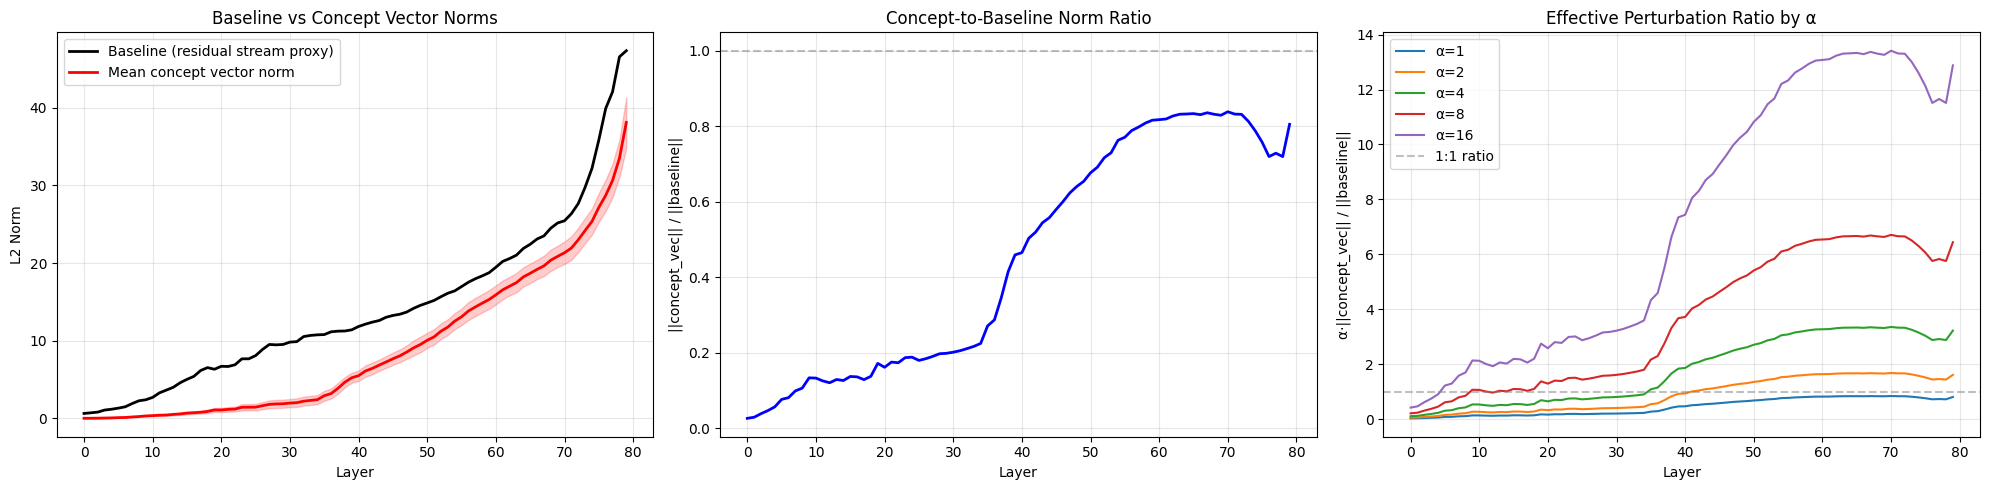

Layer ||baseline||  ||concept||    ratio    α=4 pert  α=16 pert
-----------------------------------------------------------------
    0          0.6          0.0    0.026        0.10x        0.42x
    5          1.3          0.1    0.076        0.30x        1.22x
   10          2.7          0.4    0.133        0.53x        2.12x
   15          5.0          0.7    0.137        0.55x        2.19x
   20          6.7          1.1    0.161        0.65x        2.58x
   25          8.1          1.5    0.179        0.72x        2.87x
   30          9.8          2.0    0.201        0.80x        3.22x
   35         10.8          2.9    0.271        1.08x        4.33x
   40         11.8          5.5    0.465        1.86x        7.44x
   45         13.2          7.7    0.580        2.32x        9.27x
   50         14.9         10.1    0.676        2.71x       10.82x
   55         17.0         13.1    0.771        3.08x       12.33x
   60         19.5         15.9    0.817        3.27x       13.08x

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# --- Plot 1: Baseline vs concept vector norms ---
ax = axes[0]
ax.plot(
    layers, baseline_norms, "k-", linewidth=2, label="Baseline (residual stream proxy)"
)
ax.plot(layers, mean_concept_norm, "r-", linewidth=2, label="Mean concept vector norm")
ax.fill_between(
    layers,
    mean_concept_norm - std_concept_norm,
    mean_concept_norm + std_concept_norm,
    alpha=0.2,
    color="red",
)
ax.set_xlabel("Layer")
ax.set_ylabel("L2 Norm")
ax.set_title("Baseline vs Concept Vector Norms")
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 2: Ratio of concept norm to baseline norm ---
ax = axes[1]
ratio = mean_concept_norm / (baseline_norms + 1e-8)
ax.plot(layers, ratio, "b-", linewidth=2)
ax.axhline(y=1.0, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Layer")
ax.set_ylabel("||concept_vec|| / ||baseline||")
ax.set_title("Concept-to-Baseline Norm Ratio")
ax.grid(True, alpha=0.3)

# --- Plot 3: Effective perturbation size at each α ---
ax = axes[2]
alphas = [1, 2, 4, 8, 16]
for alpha in alphas:
    effective = alpha * mean_concept_norm
    ax.plot(layers, effective / (baseline_norms + 1e-8), label=f"α={alpha}")
ax.axhline(y=1.0, color="gray", linestyle="--", alpha=0.5, label="1:1 ratio")
ax.set_xlabel("Layer")
ax.set_ylabel("α·||concept_vec|| / ||baseline||")
ax.set_title("Effective Perturbation Ratio by α")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary at key layers used in the experiment
test_layers = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 79]
print(
    f"{'Layer':>5} {'||baseline||':>12} {'||concept||':>12} {'ratio':>8}  {'α=4 pert':>10} {'α=16 pert':>10}"
)
print("-" * 65)
for l in test_layers:
    b = baseline_norms[l]
    c = mean_concept_norm[l]
    r = c / (b + 1e-8)
    print(
        f"{l:>5} {b:>12.1f} {c:>12.1f} {r:>8.3f}  {4 * c / b:>10.2f}x  {16 * c / b:>10.2f}x"
    )

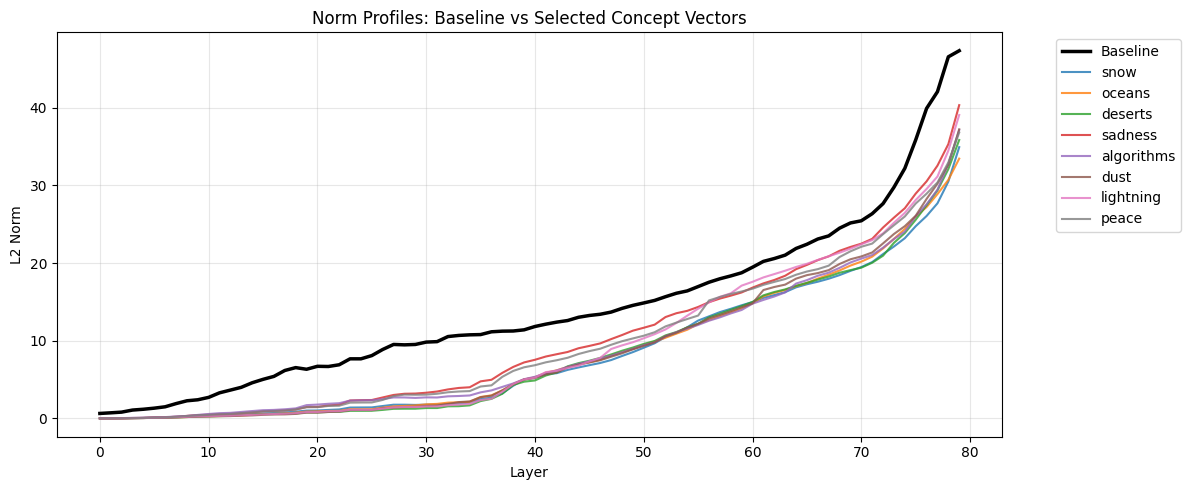

In [4]:
# Individual concept norm profiles for a few representative concepts
highlight = [
    "snow",
    "oceans",
    "deserts",
    "sadness",
    "algorithms",
    "dust",
    "lightning",
    "peace",
]
highlight = [c for c in highlight if c in concept_norms]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(layers, baseline_norms, "k-", linewidth=2.5, label="Baseline", zorder=10)
for name in highlight:
    ax.plot(layers, concept_norms[name], linewidth=1.5, label=name, alpha=0.8)
ax.set_xlabel("Layer")
ax.set_ylabel("L2 Norm")
ax.set_title("Norm Profiles: Baseline vs Selected Concept Vectors")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Experiment 1: Pairwise Cosine Similarity Matrix

Compute the pairwise cosine similarity across all 50 concept vectors at selected layers.
Semantically related concepts (e.g., snow/avalanches, oceans/deserts) should cluster together,
while unrelated ones should be far apart. If the matrix looks like noise or everything is
highly correlated, the vectors aren't encoding concept-specific information.

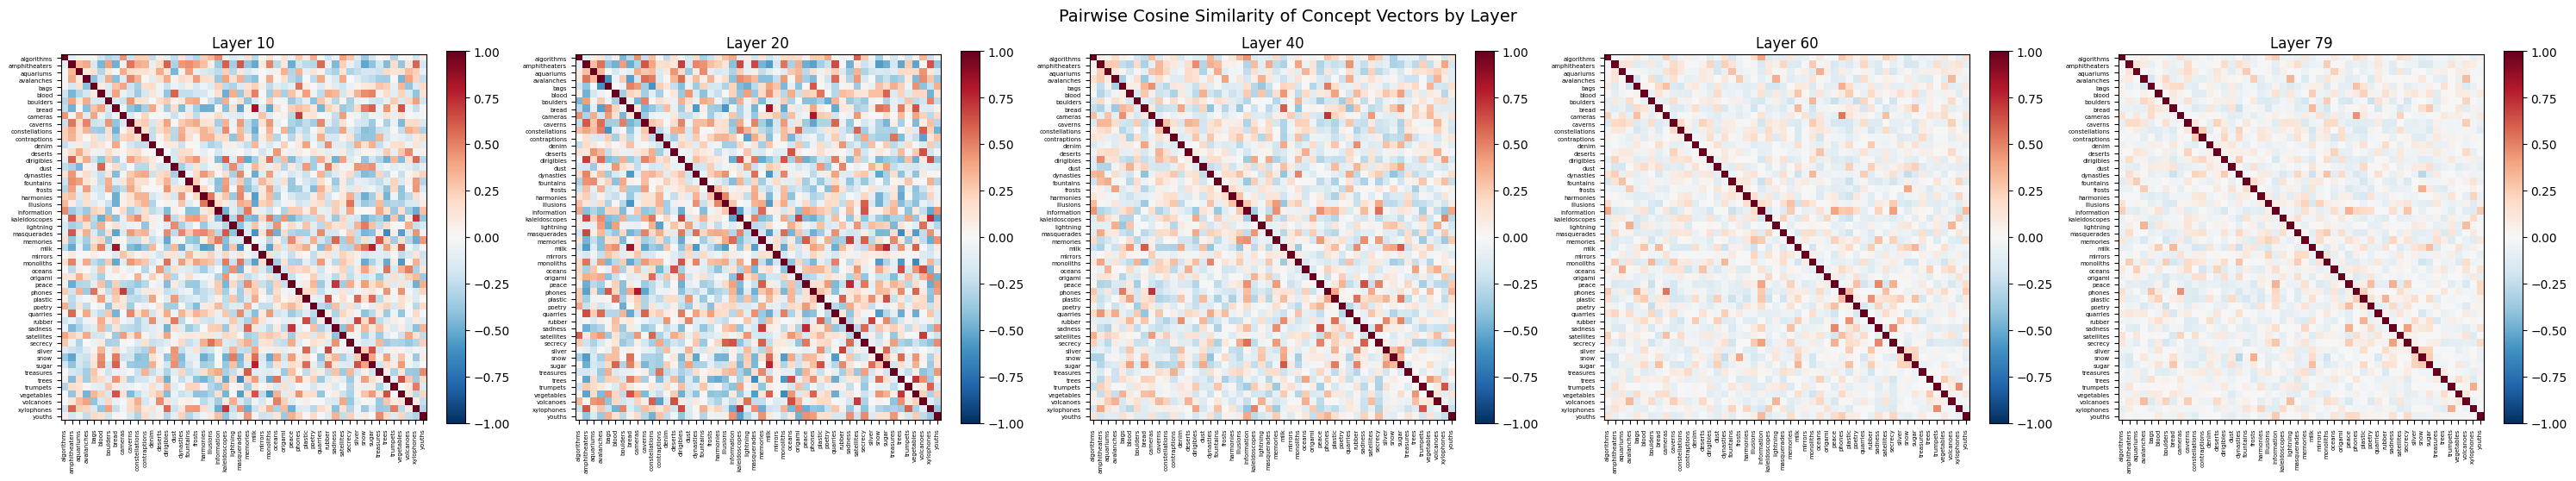

In [5]:
def compute_cosine_sim_matrix(concepts_dict, layer):
    """Compute pairwise cosine similarity at a specific layer."""
    names = list(concepts_dict.keys())
    vecs = torch.stack([concepts_dict[n][layer] for n in names])  # [n_concepts, hidden]
    # Normalize
    vecs_norm = vecs / (vecs.norm(dim=1, keepdim=True) + 1e-8)
    sim = (vecs_norm @ vecs_norm.T).numpy()
    return sim, names


# Compute at a few representative layers
diagnostic_layers = [10, 20, 40, 60, 79]

fig, axes = plt.subplots(
    1, len(diagnostic_layers), figsize=(6 * len(diagnostic_layers), 5.5)
)

for idx, layer in enumerate(diagnostic_layers):
    sim, names = compute_cosine_sim_matrix(concepts, layer)
    ax = axes[idx]
    im = ax.imshow(sim, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_title(f"Layer {layer}")
    ax.set_xticks(range(len(names)))
    ax.set_yticks(range(len(names)))
    ax.set_xticklabels(names, rotation=90, fontsize=5)
    ax.set_yticklabels(names, fontsize=5)
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle("Pairwise Cosine Similarity of Concept Vectors by Layer", fontsize=14)
plt.tight_layout()
plt.show()

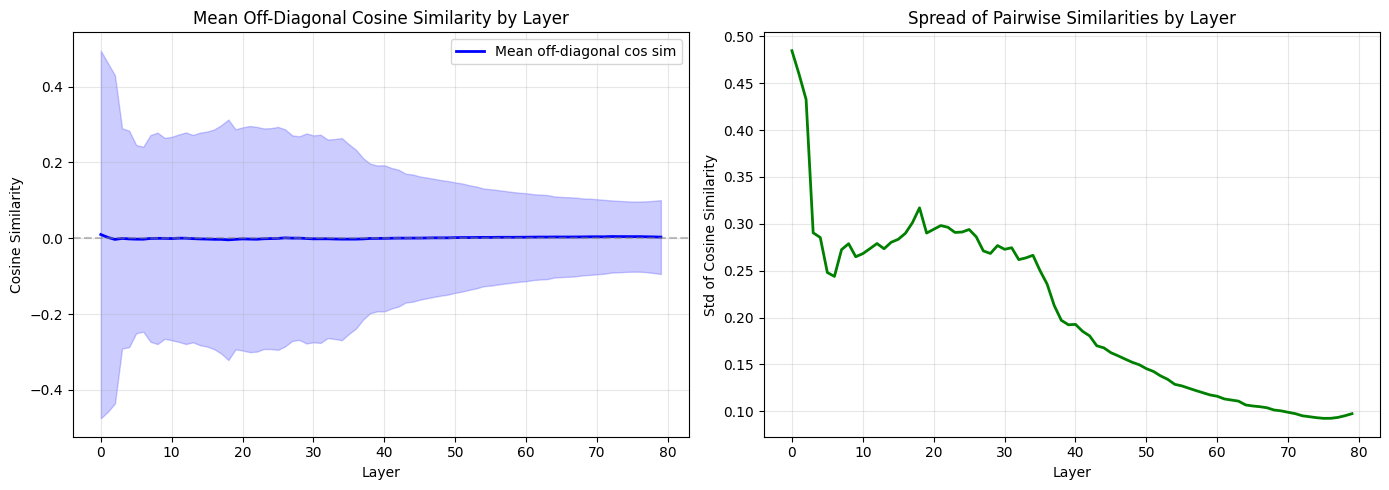

Max mean off-diagonal similarity: 0.010 at layer 0
OK: Vectors show reasonable differentiation.


In [6]:
# Summary statistics: distribution of off-diagonal similarities per layer
off_diag_stats = []
for layer in range(num_layers):
    sim, _ = compute_cosine_sim_matrix(concepts, layer)
    mask = ~np.eye(len(concept_names), dtype=bool)
    off_diag = sim[mask]
    off_diag_stats.append(
        {
            "layer": layer,
            "mean": off_diag.mean(),
            "std": off_diag.std(),
            "max": off_diag.max(),
            "min": off_diag.min(),
        }
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
means = [s["mean"] for s in off_diag_stats]
stds = [s["std"] for s in off_diag_stats]
ax.plot(layers, means, "b-", linewidth=2, label="Mean off-diagonal cos sim")
ax.fill_between(
    layers,
    np.array(means) - np.array(stds),
    np.array(means) + np.array(stds),
    alpha=0.2,
    color="blue",
)
ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Layer")
ax.set_ylabel("Cosine Similarity")
ax.set_title("Mean Off-Diagonal Cosine Similarity by Layer")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(layers, stds, "g-", linewidth=2)
ax.set_xlabel("Layer")
ax.set_ylabel("Std of Cosine Similarity")
ax.set_title("Spread of Pairwise Similarities by Layer")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Flag: if mean off-diag > 0.8 anywhere, vectors are too correlated
max_mean = max(means)
max_mean_layer = means.index(max_mean)
print(f"Max mean off-diagonal similarity: {max_mean:.3f} at layer {max_mean_layer}")
if max_mean > 0.8:
    print("WARNING: Vectors are highly correlated — they may not be concept-specific.")
elif max_mean > 0.5:
    print("CAUTION: Moderate correlation — vectors share significant common structure.")
else:
    print("OK: Vectors show reasonable differentiation.")

In [7]:
# Spot-check: cosine similarity between semantically related pairs vs random pairs
# at a mid-layer (layer 40) where steering typically works best
related_pairs = [
    ("snow", "avalanches"),
    ("snow", "frosts"),
    ("oceans", "deserts"),
    ("volcanoes", "boulders"),
    ("mirrors", "illusions"),
    ("sadness", "peace"),
    ("trumpets", "harmonies"),
    ("algorithms", "information"),
]
# Filter to pairs that exist
related_pairs = [(a, b) for a, b in related_pairs if a in concepts and b in concepts]

unrelated_pairs = [
    ("snow", "algorithms"),
    ("dust", "harmonies"),
    ("oceans", "trumpets"),
    ("sadness", "cameras"),
    ("lightning", "bread"),
    ("origami", "blood"),
    ("milk", "volcanoes"),
    ("silver", "poetry"),
]
unrelated_pairs = [
    (a, b) for a, b in unrelated_pairs if a in concepts and b in concepts
]


def cos_sim_pair(a, b, layer):
    va = concepts[a][layer]
    vb = concepts[b][layer]
    return torch.nn.functional.cosine_similarity(
        va.unsqueeze(0), vb.unsqueeze(0)
    ).item()


check_layer = 40
print(f"Cosine similarity at layer {check_layer}:")
print(f"\n{'Related pairs':>30} {'cos_sim':>8}")
print("-" * 40)
for a, b in related_pairs:
    print(f"{a + ' / ' + b:>30} {cos_sim_pair(a, b, check_layer):>8.3f}")

print(f"\n{'Unrelated pairs':>30} {'cos_sim':>8}")
print("-" * 40)
for a, b in unrelated_pairs:
    print(f"{a + ' / ' + b:>30} {cos_sim_pair(a, b, check_layer):>8.3f}")

related_sims = [cos_sim_pair(a, b, check_layer) for a, b in related_pairs]
unrelated_sims = [cos_sim_pair(a, b, check_layer) for a, b in unrelated_pairs]
print(f"\nRelated mean:   {np.mean(related_sims):.3f} ± {np.std(related_sims):.3f}")
print(f"Unrelated mean: {np.mean(unrelated_sims):.3f} ± {np.std(unrelated_sims):.3f}")

Cosine similarity at layer 40:

                 Related pairs  cos_sim
----------------------------------------
             snow / avalanches    0.026
                 snow / frosts    0.198
              oceans / deserts    0.366
          volcanoes / boulders    0.150
           mirrors / illusions    0.172
               sadness / peace    0.634
          trumpets / harmonies    0.026
      algorithms / information    0.440

               Unrelated pairs  cos_sim
----------------------------------------
             snow / algorithms   -0.313
              dust / harmonies   -0.195
             oceans / trumpets   -0.020
             sadness / cameras   -0.191
             lightning / bread   -0.013
               origami / blood   -0.115
              milk / volcanoes   -0.107
               silver / poetry   -0.017

Related mean:   0.252 ± 0.199
Unrelated mean: -0.121 ± 0.100


## Experiment 4: Baseline Subtraction Sanity Check

For a few concepts, compare the raw activation (before subtracting baseline) to the concept
vector (after subtraction). The baseline should remove a shared "I'm responding to a chat
prompt" component. If cosine similarity between raw and baseline-subtracted is ~1.0, the
baseline isn't doing much. If it's very low, the baseline might be too aggressive.

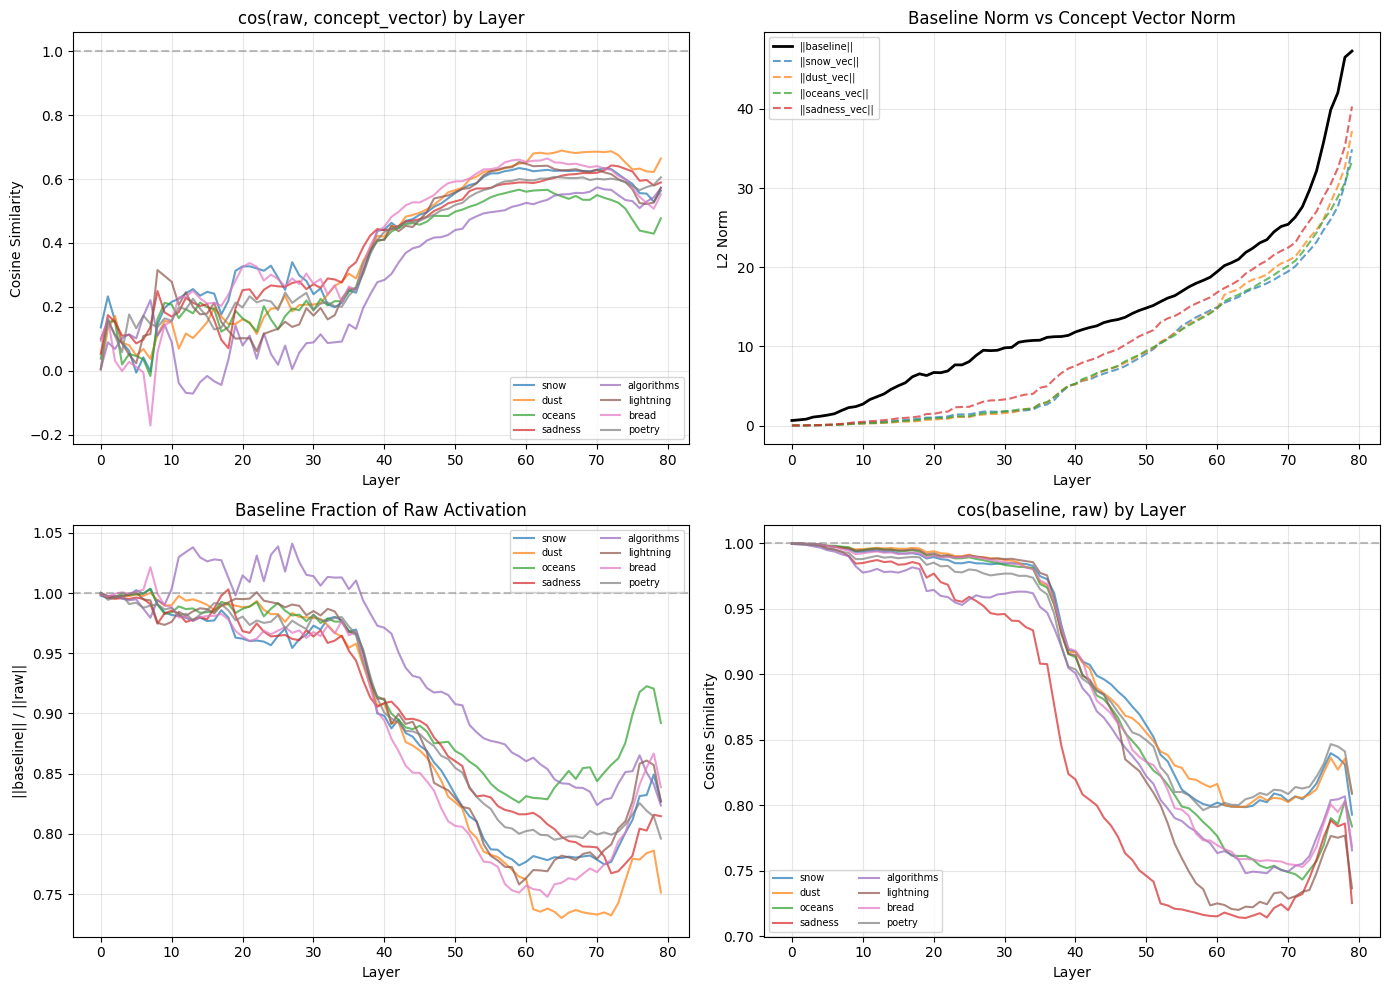

In [8]:
# Reconstruct raw activations: raw = concept_vector + baseline_mean
check_concepts = [
    "snow",
    "dust",
    "oceans",
    "sadness",
    "algorithms",
    "lightning",
    "bread",
    "poetry",
]
check_concepts = [c for c in check_concepts if c in concepts]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# --- Plot 1: Cosine similarity between raw and concept vector per layer ---
ax = axes[0]
for name in check_concepts:
    concept_vec = concepts[name]  # [num_layers, hidden]
    raw = concept_vec + baseline_mean  # reconstruct raw activation
    # Per-layer cosine similarity
    cos_per_layer = torch.nn.functional.cosine_similarity(
        raw, concept_vec, dim=1
    ).numpy()
    ax.plot(layers, cos_per_layer, label=name, alpha=0.7)
ax.axhline(y=1.0, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Layer")
ax.set_ylabel("Cosine Similarity")
ax.set_title("cos(raw, concept_vector) by Layer")
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

# --- Plot 2: Norm of baseline vs norm of concept vector ---
ax = axes[1]
ax.plot(layers, baseline_norms, "k-", linewidth=2, label="||baseline||")
for name in check_concepts[:4]:
    ax.plot(layers, concept_norms[name], "--", label=f"||{name}_vec||", alpha=0.7)
ax.set_xlabel("Layer")
ax.set_ylabel("L2 Norm")
ax.set_title("Baseline Norm vs Concept Vector Norm")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# --- Plot 3: Fraction of raw activation "explained" by baseline ---
# ||baseline|| / ||raw|| measures how much of the activation is shared/baseline
ax = axes[2]
for name in check_concepts:
    raw = concepts[name] + baseline_mean
    raw_norms = raw.norm(dim=1).numpy()
    fraction = baseline_norms / (raw_norms + 1e-8)
    ax.plot(layers, fraction, label=name, alpha=0.7)
ax.axhline(y=1.0, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Layer")
ax.set_ylabel("||baseline|| / ||raw||")
ax.set_title("Baseline Fraction of Raw Activation")
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

# --- Plot 4: Cosine similarity between baseline and raw ---
ax = axes[3]
for name in check_concepts:
    raw = concepts[name] + baseline_mean
    cos_bl_raw = torch.nn.functional.cosine_similarity(
        baseline_mean, raw, dim=1
    ).numpy()
    ax.plot(layers, cos_bl_raw, label=name, alpha=0.7)
ax.axhline(y=1.0, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Layer")
ax.set_ylabel("Cosine Similarity")
ax.set_title("cos(baseline, raw) by Layer")
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# Numerical summary at key layers
print(
    f"{'Concept':>12} {'Layer':>5} {'cos(raw,cv)':>12} {'cos(bl,raw)':>12} {'||bl||/||raw||':>14} {'||cv||/||raw||':>14}"
)
print("-" * 75)
for name in check_concepts:
    concept_vec = concepts[name]
    raw = concept_vec + baseline_mean
    for l in [20, 40, 60]:
        cv = concept_vec[l]
        r = raw[l]
        bl = baseline_mean[l]
        cos_raw_cv = torch.nn.functional.cosine_similarity(
            r.unsqueeze(0), cv.unsqueeze(0)
        ).item()
        cos_bl_raw = torch.nn.functional.cosine_similarity(
            bl.unsqueeze(0), r.unsqueeze(0)
        ).item()
        bl_frac = bl.norm().item() / (r.norm().item() + 1e-8)
        cv_frac = cv.norm().item() / (r.norm().item() + 1e-8)
        print(
            f"{name:>12} {l:>5} {cos_raw_cv:>12.4f} {cos_bl_raw:>12.4f} {bl_frac:>14.4f} {cv_frac:>14.4f}"
        )

     Concept Layer  cos(raw,cv)  cos(bl,raw) ||bl||/||raw|| ||cv||/||raw||
---------------------------------------------------------------------------
        snow    20       0.3267       0.9896         0.9621         0.1466
        snow    40       0.4422       0.9172         0.8980         0.3989
        snow    60       0.6305       0.8020         0.7769         0.5978
        dust    20       0.1616       0.9940         0.9882         0.1097
        dust    40       0.4195       0.9170         0.9080         0.3989
        dust    60       0.6512       0.8163         0.7622         0.5801
      oceans    20       0.1643       0.9911         0.9869         0.1333
      oceans    40       0.4122       0.9131         0.9111         0.4078
      oceans    60       0.5604       0.7765         0.8313         0.6326
     sadness    20       0.2526       0.9769         0.9683         0.2137
     sadness    40       0.4402       0.8197         0.9087         0.5797
     sadness    60      

   lightning    20       0.1024       0.9924         0.9950         0.1230
   lightning    40       0.4096       0.9146         0.9123         0.4043
   lightning    60       0.6474       0.7251         0.7633         0.6897
       bread    20       0.3249       0.9907         0.9639         0.1389
       bread    40       0.4511       0.9180         0.8941         0.3973
       bread    60       0.6535       0.7695         0.7571         0.6388
      poetry    20       0.1987       0.9853         0.9805         0.1710
      poetry    40       0.4349       0.9038         0.9005         0.4280
      poetry    60       0.5969       0.7988         0.8024         0.6016


## Experiment 2: Steering Generation (requires NDIF)

Inject a concept vector into a neutral prompt and check whether the model's generation shifts
toward that concept. This is the definitive test — if steering doesn't work at *any*
layer/strength combination, the vectors are broken.

**Note:** This requires nnsight remote execution via NDIF.

In [14]:
import os
from dotenv import load_dotenv

load_dotenv()
MODEL = "meta-llama/Llama-3.3-70B-Instruct"
model = None

try:
    import nnsight
except Exception as e:
    print(f"Skipping Experiment 2: nnsight import failed ({e}).")
else:
    ndif_key = os.environ.get("NDIF_API_KEY")
    if not ndif_key:
        print("Skipping Experiment 2: NDIF_API_KEY is not set.")
    else:
        try:
            nnsight.CONFIG.set_default_api_key(ndif_key)
            if not nnsight.is_model_running(MODEL):
                print(f"Skipping Experiment 2: {MODEL} is not online in NDIF.")
            else:
                model = nnsight.LanguageModel(MODEL)
                print(f"Model loaded: {MODEL}")
        except Exception as e:
            print(f"Skipping Experiment 2: NDIF setup failed ({e}).")

Model loaded: meta-llama/Llama-3.3-70B-Instruct


In [12]:
def steer_and_generate(
    model, concept_vec_all_layers, layer, alpha, neutral_prompt, max_new_tokens=48
):
    """
    Inject concept_vec * alpha into the residual stream at `layer` for all token positions,
    then generate text.
    """
    if model is None:
        raise RuntimeError("Model is not initialized. Configure NDIF first.")

    messages = [{"role": "user", "content": neutral_prompt}]
    prompt = model.tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

    steering_vec = concept_vec_all_layers[layer]

    with model.generate(
        prompt, max_new_tokens=max_new_tokens, do_sample=False, remote=True
    ):
        layer_out = model.model.layers[layer].output[0]
        steering = (alpha * steering_vec).to(
            device=layer_out.device, dtype=layer_out.dtype
        )
        layer_out[:] += steering
        out_ids = model.generator.output.save()

    return model.tokenizer.decode(out_ids[0], skip_special_tokens=True)

In [13]:
# First, generate a baseline (no steering) for comparison
neutral_prompt = "Tell me about today."

if model is None:
    baseline_text = ""
    print("Skipping baseline generation because NDIF model is unavailable.")
else:
    messages = [{"role": "user", "content": neutral_prompt}]
    prompt = model.tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

    with model.generate(prompt, max_new_tokens=100, do_sample=False, remote=True):
        baseline_ids = model.generator.output.save()

    baseline_text = model.tokenizer.decode(baseline_ids[0], skip_special_tokens=True)
    print("=== BASELINE (no steering) ===")
    print(baseline_text)
    print()

NameError: name 'model' is not defined

In [15]:
# Test steering with a few concepts across layers and alpha values
RUN_FULL_STEERING_SWEEP = True

if RUN_FULL_STEERING_SWEEP:
    test_concepts = ["snow", "oceans", "lightning", "sadness"]
    test_layers = [20, 30, 40]  # broader mid-layer sweep
    test_alphas = [4, 8, 16]
else:
    # Fast default path for notebook reliability in CI/local reruns.
    test_concepts = ["snow", "oceans"]
    test_layers = [30]
    test_alphas = [8]

test_concepts = [c for c in test_concepts if c in concepts]

results = []

if model is None:
    print("Skipping steering runs because NDIF model is unavailable.")
else:
    print(
        f"Running steering sweep with {len(test_concepts)} concept(s), "
        f"{len(test_layers)} layer(s), {len(test_alphas)} alpha value(s)."
    )
    for concept_name in test_concepts:
        concept_vec = concepts[concept_name]
        for layer in test_layers:
            for alpha in test_alphas:
                print(f"--- {concept_name} | layer={layer} | α={alpha} ---")
                try:
                    text = steer_and_generate(
                        model, concept_vec, layer, alpha, neutral_prompt
                    )
                    response = (
                        text.split(neutral_prompt)[-1].strip()
                        if neutral_prompt in text
                        else text
                    )
                    print(response[:300])
                    print()
                    results.append(
                        {
                            "concept": concept_name,
                            "layer": layer,
                            "alpha": alpha,
                            "response": response,
                        }
                    )
                except Exception as e:
                    print(f"  ERROR: {e}")
                    print()

Running steering sweep with 4 concept(s), 3 layer(s), 3 alpha value(s).
--- snow | layer=20 | α=4 ---


⬇ Downloading:   0%|          | 0.00/2.35k [00:00<?]

assistant

I'm a large language model, I don't have real-time access to the current date or time. My training data only goes up to 2022, so I don't have information about the current day or any events that may be

--- snow | layer=20 | α=8 ---


⬇ Downloading:   0%|          | 0.00/2.35k [00:00<?]

assistant

I'm a large language model, I don't have real-time access to the current date or time. I'm a static model that was trained on a dataset that only goes up to 2022, so I don't have information about

--- snow | layer=20 | α=16 ---


...

assistant

I don't have real-time access to the current date or time. My training data only goes up to 2023, so I don't have information about the current day or any events that may have occurred after that. If you're

--- sadness | layer=40 | α=8 ---


⬇ Downloading:   0%|          | 0.00/2.35k [00:00<?]

assistant

\, 
I don't have access to the current state of the world and the date. 
If you need information about something specific, I'll do my best to help. 
I can provide information about various topics, help with tasks

--- sadness | layer=40 | α=16 ---


⬇ Downloading:   0%|          | 0.00/2.35k [00:00<?]

assistant

 heavless, as a long, long, long, long, long, long, long, long, long, long, long, long, long, long, long, long, long, long, long, long, long, long



In [16]:
# Quick keyword check: does the steered output mention the target concept?
if results:
    print(
        f"{'Concept':>12} {'Layer':>5} {'Alpha':>5} {'Concept in output?':>20} {'First 80 chars'}"
    )
    print("-" * 130)
    for r in results:
        contains = r["concept"] in r["response"].lower()
        preview = r["response"][:80].replace("\n", " ")
        print(
            f"{r['concept']:>12} {r['layer']:>5} {r['alpha']:>5} {'YES' if contains else 'no':>20} {preview}"
        )

     Concept Layer Alpha   Concept in output? First 80 chars
----------------------------------------------------------------------------------------------------------------------------------
        snow    20     4                   no assistant  I'm a large language model, I don't have real-time access to the curr
        snow    20     8                   no assistant  I'm a large language model, I don't have real-time access to the curr
        snow    20    16                   no assistant  I'm happy to chat with you! However, I'm a large language model, I do
        snow    30     4                   no assistant  I'm happy to chat with you, but I'm a large language model, I don't h
        snow    30     8                   no assistant  It's a brand new day! The sun is shining, the birds are singing, and 
        snow    30    16                   no assistant  It's currently December 2023, and I am an AI, so I don't have have ac
        snow    40     4                   no 